# Background: Shear-Wave Splitting at Axial Seamount

## Shear-Wave Splitting

Shear-wave splitting (SWS), also known as seismic birefringence, is a phenomenon that occurs when a shear wave travels through an anisotropic medium. As the wave enters the anisotropic region, it splits into two orthogonally polarized waves that travel at different velocities. These two waves are typically referred to as the "fast" and "slow" components. The time delay between the arrival of these two waves (δt) and the polarization direction of the fast wave (φ) provide valuable information about the anisotropic properties of the medium.

Seismic anisotropy in the Earth can be caused by several mechanisms:
1. **Aligned cracks or fractures**: In the upper crust, aligned fluid-filled cracks or fractures can cause shear-wave splitting
2. **Mineral alignment**: Preferred orientation of anisotropic minerals like olivine in the mantle
3. **Stress-aligned microcracks**: In volcanic regions, ambient stress fields can align microcracks
4. **Layered structures**: Alternating thin layers with different elastic properties

## Axial Seamount

Axial Seamount is an active submarine volcano located on the Juan de Fuca Ridge in the northeastern Pacific Ocean, approximately 300 miles off the coast of Oregon. As the most active volcano on the western boundary of the Juan de Fuca tectonic plate, it has been the site of multiple eruptions in recent decades (1998, 2011, 2015). 

The volcano features a caldera at its summit and is characterized by its unique setting at the intersection of a mid-ocean ridge and a hotspot. This geological context makes Axial Seamount an excellent natural laboratory for studying magmatic systems, crustal deformation, and hydrothermal processes. The volcano is heavily instrumented as part of the Ocean Observatories Initiative, providing real-time seismic, geodetic, and hydrothermal data.

Studying shear-wave splitting at Axial Seamount offers insights into:
- The orientation of magma pathways and storage systems
- Regional stress fields and how they evolve during volcanic activity
- Crustal fracture systems that facilitate hydrothermal circulation
- Potential precursory changes before eruptions

## Theoretical Background on Analysis Methods

### Silver and Chan (1991) Method

The Silver and Chan (1991) method is a foundational approach for measuring shear-wave splitting parameters. It uses the minimum eigenvalue method to determine the splitting parameters that best correct for the effects of anisotropy. The key principles include:

1. **Inverse splitting operator**: The method applies trial corrections to the split waveform by testing different combinations of fast direction (φ) and delay time (δt)
2. **Covariance matrix analysis**: For each combination, it calculates the covariance matrix of the corrected horizontal components
3. **Minimum eigenvalue criterion**: The optimal splitting parameters are those that minimize the second eigenvalue of the covariance matrix, which effectively linearizes the particle motion that was elliptical due to splitting
4. **Confidence regions**: The method also provides statistical measures of confidence in the results through an F-test on the eigenvalue surface

### Teanby et al. (2004) Clustering Method

Teanby et al. (2004) extended the Silver and Chan approach by introducing a cluster analysis method to improve the robustness of splitting measurements:

1. **Multiple time windows**: Instead of analyzing a single window around the S-wave arrival, the method performs the analysis on many different time windows
2. **Stability assessment**: Results from these windows are compared to identify stable regions in parameter space
3. **Cluster analysis**: Measurements are grouped into clusters to identify consistent results
4. **Optimal window selection**: The final splitting parameters are determined from the most stable cluster, reducing the dependence on subjective window selection

### SWSPy Implementation

The SWSPy package implements these methods with additional features:

1. **Automated processing**: Streamlines the analysis of large seismic datasets
2. **Multiple coordinate systems**: Allows analysis in ZNE (vertical, north, east) or LQT (ray-based) coordinate systems
3. **Quality control**: Provides measures to assess the reliability of splitting measurements
4. **Visualization tools**: Generates diagnostic plots for interpreting results

In this notebook, we implement a workflow for applying these methods to seismic data from Axial Seamount, with the goal of mapping anisotropy patterns and understanding their relationship to volcanic and hydrothermal processes.

# Streamlined Shear-Wave Splitting Analysis Workflow

This notebook demonstrates a streamlined workflow for analyzing shear-wave splitting in seismic data. The process includes:

1. Loading and filtering earthquake catalog data
2. Retrieving waveforms for a subset of events
3. Processing and visualizing seismogram components 
4. Performing shear-wave splitting analysis using SWSPy
5. Interpreting and visualizing the results

This approach can be applied to larger datasets with minimal modifications.

## 1. Import Required Libraries

In [37]:
# Standard libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ObsPy for seismic data processing
import obspy
from obspy.core.utcdatetime import UTCDateTime

# SWSPy for shear-wave splitting analysis
import swspy

# Add the scripts directory to path to import custom modules
scripts_path = os.path.join('..', 'scripts')
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

# Import custom modules
try:
    from get_all_traces import get_all_traces
    from seismic_geometry import calculate_back_azimuth, calculate_angle_of_incidence, calculate_epicentral_distance_km
    print("Successfully imported custom modules")
except ImportError as e:
    print(f"Warning: Could not import custom modules: {e}")
    print("Please ensure the necessary modules are in the scripts directory")

Successfully imported custom modules


In [3]:
def calculate_p_wave_metrics(stream, event_row, window_start_sec=-0.02, window_end_sec=0.1):
    """
    Calculate P-wave rectilinearity and angle of incidence for a specific event.
    
    Parameters:
    -----------
    stream : obspy.Stream
        The full stream containing waveform data
    event_row : pandas.Series
        Row from the catalog containing event information
    window_start_sec : float
        Start of the window relative to P-arrival time (default: -0.02 seconds)
    window_end_sec : float
        End of the window relative to P-arrival time (default: 0.1 seconds)
        
    Returns:
    --------
    dict
        Dictionary with 'rectilinearity' and 'incidence_angle' values
    """
    # Extract event information
    event_time = UTCDateTime(event_row['datetime'])
    station_id = event_row['station_id']
    p_arrival_time = event_row['p_arrival_time']
    
    print(f"Processing event at {event_time}, station: {station_id}, P arrival: {p_arrival_time}")
    
    # Handle missing P-arrival time
    if pd.isna(p_arrival_time):
        print(f"  Missing P-arrival time for event")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    # Calculate window times
    p_pick_time = event_time + float(p_arrival_time)
    window_start = p_pick_time + window_start_sec
    window_end = p_pick_time + window_end_sec
    
    print(f"  P-pick time: {p_pick_time}")
    print(f"  Window: {window_start} to {window_end}")
    
    # Select data for this station
    st_station = stream.select(station=station_id)
    print(f"  Found {len(st_station)} traces for station {station_id}")
    
    if len(st_station) < 3:
        print(f"  Insufficient traces for station {station_id}")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    # Create separate streams for each component
    st_z = obspy.Stream()
    st_n = obspy.Stream()
    st_e = obspy.Stream()
    
    # Identify component traces
    for tr in st_station:
        # Get the last character of the channel code
        component = tr.stats.channel[-1].upper()
        print(f"  Channel: {tr.stats.channel}, Component: {component}, Time range: {tr.stats.starttime} - {tr.stats.endtime}")
        
        # Add to appropriate component stream
        if component == 'Z':
            st_z.append(tr.copy())
        elif component in ['N', '1']:
            st_n.append(tr.copy())
        elif component in ['E', '2']:
            st_e.append(tr.copy())
    
    # Check if we found all components
    if len(st_z) == 0:
        print("  No Z component found")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    if len(st_n) == 0:
        print("  No N component found")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    if len(st_e) == 0:
        print("  No E component found")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    # Get one trace for each component (first one if multiple)
    tr_z = st_z[0]
    tr_n = st_n[0]
    tr_e = st_e[0]
    
    # Check if all traces cover the required time window
    traces_cover_window = (
        tr_z.stats.starttime <= window_start and tr_z.stats.endtime >= window_end and
        tr_n.stats.starttime <= window_start and tr_n.stats.endtime >= window_end and
        tr_e.stats.starttime <= window_start and tr_e.stats.endtime >= window_end
    )
    
    if not traces_cover_window:
        print("  Traces don't cover the required time window")
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
    
    try:
        # Extract the windowed data
        z_data = tr_z.slice(window_start, window_end).data
        n_data = tr_n.slice(window_start, window_end).data
        e_data = tr_e.slice(window_start, window_end).data
        
        print(f"  Data lengths: Z={len(z_data)}, N={len(n_data)}, E={len(e_data)}")
        
        # Make all arrays the same length
        min_length = min(len(z_data), len(n_data), len(e_data))
        if min_length < 3:
            print(f"  Insufficient data points ({min_length})")
            return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
        
        # Trim to same length
        z_data = z_data[:min_length]
        n_data = n_data[:min_length]
        e_data = e_data[:min_length]
        
        # Stack into matrix (Z, N, E order)
        X = np.vstack([z_data, n_data, e_data]).T
        X = X - np.mean(X, axis=0)  # Zero-mean the data
        
        # Check for valid data
        if np.all(np.isclose(X, 0)) or np.isnan(X).any():
            print("  Data contains all zeros or NaNs")
            return {'rectilinearity': np.nan, 'incidence_angle': np.nan}
        
        # Compute covariance matrix
        cov = np.cov(X, rowvar=False)
        
        # Eigenvalue decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        
        # Sort eigenvalues in descending order
        idx = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # Calculate rectilinearity
        if eigenvalues[0] > 1e-10:
            rectilinearity = 1.0 - (eigenvalues[1] + eigenvalues[2]) / (2.0 * eigenvalues[0])
        else:
            rectilinearity = 0.0
        
        # Calculate incidence angle
        # Z component is first in our stack, so it's the first row (index 0)
        z_component = eigenvectors[0, 0]  # First row (Z), first column (principal eigenvector)
        z_component_abs = abs(z_component)
        
        # Ensure valid domain for arccos
        if z_component_abs > 1.0:
            z_component_abs = 1.0
            
        incidence_angle = np.degrees(np.arccos(z_component_abs))
        
        print(f"  SUCCESS - rectilinearity: {rectilinearity:.3f}, incidence angle: {incidence_angle:.1f}°")
        
        return {
            'rectilinearity': float(rectilinearity),
            'incidence_angle': float(incidence_angle)
        }
        
    except Exception as e:
        print(f"  ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return {'rectilinearity': np.nan, 'incidence_angle': np.nan}


def process_catalog_p_wave_metrics(stream, catalog):
    """
    Process all events in a catalog to calculate P-wave metrics.
    
    Parameters:
    -----------
    stream : obspy.Stream
        Stream containing all waveform data
    catalog : pandas.DataFrame
        Catalog of events
    
    Returns:
    --------
    pandas.DataFrame
        Updated catalog with P-wave metrics
    """
    # Make a deep copy of the catalog to avoid modifying the original
    updated_catalog = catalog.copy()
    
    # Make a deep copy of the stream to avoid modifying the original
    stream_copy = stream.copy()
    
    # Add columns for P-wave metrics if they don't exist
    if 'rectilinearity' not in updated_catalog.columns:
        updated_catalog['rectilinearity'] = np.nan
        
    if 'incidence_angle' not in updated_catalog.columns:
        updated_catalog['incidence_angle'] = np.nan
    
    # Get the total number of events
    total_events = len(updated_catalog)
    print(f"Processing P-wave metrics for {total_events} events...")
    
    # Track success count
    success_count = 0
    
    # Process each event
    for i, (idx, event) in enumerate(updated_catalog.iterrows()):
        print(f"\n[Event {i+1}/{total_events}] ID: {event.get('event_id', idx)}")
        
        # Calculate P-wave metrics
        metrics = calculate_p_wave_metrics(stream_copy, event)
        
        # Update the catalog with results
        updated_catalog.at[idx, 'rectilinearity'] = metrics['rectilinearity']
        updated_catalog.at[idx, 'incidence_angle'] = metrics['incidence_angle']
        
        # Track success
        if not np.isnan(metrics['rectilinearity']) and not np.isnan(metrics['incidence_angle']):
            success_count += 1
            print(f"✓ Success for event {i+1}")
        else:
            print(f"✗ Failed for event {i+1}")
        
        # Print progress every 5 events
        if (i + 1) % 5 == 0 or i == total_events - 1:
            success_rate = (success_count / (i + 1)) * 100
            print(f"\nProgress: {i + 1}/{total_events} events ({(i + 1)/total_events:.1%})")
            print(f"Success rate so far: {success_count}/{i+1} ({success_rate:.1f}%)")
    
    # Final summary
    success_rate = (success_count / total_events) * 100
    print(f"\n{'='*70}")
    print(f"PROCESSING COMPLETE: {success_count}/{total_events} successful ({success_rate:.1f}%)")
    print(f"{'='*70}")
    
    return updated_catalog

## 2. Load and Filter Earthquake Catalog

We'll use a small version of the catalog (100 events) for demonstration purposes. In a real analysis, you would use the full catalog.

In [4]:
# Load the catalog
# Use the small 100 events catalog for example purposes
# catalog = pd.read_csv('../data/small_catalog_100_events.csv')

#catalog = pd.read_csv('../data/old_catalog_with_geometry_filtered_100.csv')
catalog = pd.read_csv('../data/extended_catalog_for_snr.csv')

print(f"Loaded catalog with {len(catalog)} rows and {len(catalog.columns)} columns")
print(f"Catalog columns: {catalog.columns.tolist()}")

# Display first few rows of the catalog
display(catalog.head())

Loaded catalog with 2 rows and 24 columns
Catalog columns: ['event_id', 'year', 'lat', 'lon', 'depth', 'magnitude', 'datetime', 'station_id', 'station_lat', 'station_lon', 'station_elev', 'back_azimuth', 'epicentral_distance_km', 'angle_of_incidence', 'endtime', 'p_arrival_time', 's_arrival_time', 'rectilinearity', 'incidence_angle', 'snr_e', 'snr_n', 'snr_horizontal', 'extended_start', 's_arrival']


,event_id,year,lat,lon,depth,magnitude,datetime,station_id,station_lat,station_lon,...,endtime,p_arrival_time,s_arrival_time,rectilinearity,incidence_angle,snr_e,snr_n,snr_horizontal,extended_start,s_arrival
0,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC1,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.955643,3.335806,5.091918,6.194694,5.643306,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z
1,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC2,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.947564,17.237530,4.070781,0.760443,2.415612,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z


In [5]:
# Check if the catalog is already filtered by angle of incidence <= 30 degrees
if 'angle_of_incidence' in catalog.columns:
    aoi_range = (catalog['angle_of_incidence'].min(), catalog['angle_of_incidence'].max())
    print(f"Angle of incidence range in catalog: {aoi_range[0]:.1f} to {aoi_range[1]:.1f} degrees")
    
    if aoi_range[1] > 30.0:
        print("Filtering catalog to include only events with angle of incidence <= 30 degrees...")
        catalog = catalog[catalog['angle_of_incidence'] <= 30.0]
        print(f"Catalog now has {len(catalog)} events after filtering")
    else:
        print("Catalog already filtered by angle of incidence <= 30 degrees")
else:
    print("Warning: 'angle_of_incidence' column not found in catalog")
    print("Make sure to run seismic_geometry_analysis.ipynb first")

Angle of incidence range in catalog: 27.1 to 27.1 degrees
Catalog already filtered by angle of incidence <= 30 degrees


## Import and Process MSEED Data

In [6]:
# Import the MSEED file containing our waveform data
# Use 'sample_waveforms.mseed' if it exists, otherwise specify the correct path
#mseed_file = "old_catalog_waveforms_100.mseed"  # Update this if your file is named differently
mseed_file = "extended_catalog_waveforms_for_snr.mseed"  # Update this if your file is named differently

try:
    st = obspy.read(mseed_file)
    print(f"Successfully loaded {len(st)} traces from {mseed_file}")
    print(f"Time range: {st[0].stats.starttime} to {st[-1].stats.endtime}")
    
    # Get a list of stations and channels in the dataset
    stations = sorted(set(tr.stats.station for tr in st))
    channels = sorted(set(tr.stats.channel for tr in st))
    
    print(f"\nStations in dataset: {', '.join(stations)}")
    print(f"Channels in dataset: {', '.join(channels)}")
    
    # Count traces per station
    station_counts = {}
    for station in stations:
        count = len([tr for tr in st if tr.stats.station == station])
        station_counts[station] = count
    
    print("\nTraces per station:")
    for station, count in station_counts.items():
        print(f"  {station}: {count} traces")
    
    # CRITICAL: Analyze the stream structure to understand timing
    print(f"\n{'='*60}")
    print("STREAM STRUCTURE ANALYSIS")
    print(f"{'='*60}")
    
    # Check unique start times
    unique_start_times = sorted(set(tr.stats.starttime for tr in st))
    print(f"Number of unique start times: {len(unique_start_times)}")
    
    if len(unique_start_times) <= 10:  # If reasonable number, show them all
        for i, start_time in enumerate(unique_start_times):
            traces_at_time = [tr for tr in st if tr.stats.starttime == start_time]
            print(f"  Start time {i+1}: {start_time} - {len(traces_at_time)} traces")
    else:
        print(f"  First start time: {unique_start_times[0]}")
        print(f"  Last start time: {unique_start_times[-1]}")
        print(f"  Time span: {unique_start_times[-1] - unique_start_times[0]} seconds")
    
    # Analyze trace timing for each station
    print(f"\nTRACE TIMING BY STATION:")
    for station in stations:
        st_station = st.select(station=station)
        start_times = [tr.stats.starttime for tr in st_station]
        end_times = [tr.stats.endtime for tr in st_station]
        
        print(f"\n{station}:")
        print(f"  Number of traces: {len(st_station)}")
        print(f"  Earliest start: {min(start_times)}")
        print(f"  Latest end: {max(end_times)}")
        print(f"  Total coverage: {max(end_times) - min(start_times)} seconds")
        
        # Check for gaps or overlaps
        if len(set(start_times)) > 1:
            print(f"  WARNING: Multiple start times detected - may indicate concatenated events")
    
except Exception as e:
    print(f"Error loading MSEED file: {e}")
    print("Please ensure the file exists and is correctly specified.")
    print("You may need to uncomment the get_all_traces function call above to create the file.")

Successfully loaded 54 traces from extended_catalog_waveforms_for_snr.mseed
Time range: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z

Stations in dataset: AXAS1, AXAS2, AXBA1, AXCC1, AXEC1, AXEC2, AXEC3, AXID1
Channels in dataset: EHE, EHN, EHZ, HDH, HHE, HHN, HHZ

Traces per station:
  AXAS1: 6 traces
  AXAS2: 6 traces
  AXBA1: 8 traces
  AXCC1: 8 traces
  AXEC1: 6 traces
  AXEC2: 8 traces
  AXEC3: 6 traces
  AXID1: 6 traces

STREAM STRUCTURE ANALYSIS
Error loading MSEED file: __hash__ method should return an integer
Please ensure the file exists and is correctly specified.
You may need to uncomment the get_all_traces function call above to create the file.


In [7]:
def organize_stream_by_events(stream, catalog, time_tolerance=5.0):
    """
    Organize the stream data by matching traces to catalog events.
    
    Parameters:
    -----------
    stream : obspy.Stream
        The full stream containing all waveform data
    catalog : pandas.DataFrame
        Catalog of events with datetime and station information
    time_tolerance : float
        Tolerance in seconds for matching trace start times to event times
        
    Returns:
    --------
    dict
        Dictionary mapping event indices to their corresponding stream data
    """
    event_streams = {}
    
    print(f"Organizing stream data for {len(catalog)} events...")
    
    for i, (idx, event) in enumerate(catalog.iterrows()):
        event_time = UTCDateTime(event['datetime'])
        station_id = event['station_id']
        
        # Find traces that match this event's time and station
        matching_traces = []
        
        for tr in stream.select(station=station_id):
            # Check if trace start time is close to event time
            time_diff = abs(tr.stats.starttime - event_time)
            
            if time_diff <= time_tolerance:
                matching_traces.append(tr.copy())
        
        if len(matching_traces) >= 3:  # Need at least Z, N, E components
            event_stream = obspy.Stream(matching_traces)
            event_streams[idx] = event_stream
            print(f"  Event {i+1}: Found {len(matching_traces)} traces for {station_id} at {event_time}")
        else:
            print(f"  Event {i+1}: Only {len(matching_traces)} traces found for {station_id} at {event_time}")
            event_streams[idx] = None
    
    return event_streams

def calculate_p_wave_metrics_fixed(event_streams, catalog):
    """
    Calculate P-wave metrics using properly organized event streams.
    
    Parameters:
    -----------
    event_streams : dict
        Dictionary mapping event indices to their stream data
    catalog : pandas.DataFrame
        Catalog of events
        
    Returns:
    --------
    pandas.DataFrame
        Updated catalog with P-wave metrics
    """
    # Make a copy of the catalog
    updated_catalog = catalog.copy()
    
    # Add columns for metrics
    if 'rectilinearity' not in updated_catalog.columns:
        updated_catalog['rectilinearity'] = np.nan
    if 'incidence_angle' not in updated_catalog.columns:
        updated_catalog['incidence_angle'] = np.nan
    
    success_count = 0
    total_events = len(catalog)
    
    print(f"\nCalculating P-wave metrics for {total_events} events...")
    
    for i, (idx, event) in enumerate(updated_catalog.iterrows()):
        print(f"\n[Event {i+1}/{total_events}] ID: {event.get('event_id', idx)}")
        
        # Get the stream for this event
        event_stream = event_streams.get(idx)
        
        if event_stream is None:
            print(f"  No stream data available for this event")
            continue
        
        # Calculate metrics using the existing function but with proper event stream
        metrics = calculate_p_wave_metrics(event_stream, event)
        
        # Update the catalog
        updated_catalog.at[idx, 'rectilinearity'] = metrics['rectilinearity']
        updated_catalog.at[idx, 'incidence_angle'] = metrics['incidence_angle']
        
        # Track success
        if not np.isnan(metrics['rectilinearity']) and not np.isnan(metrics['incidence_angle']):
            success_count += 1
            print(f"  ✓ Success: rect={metrics['rectilinearity']:.3f}, angle={metrics['incidence_angle']:.1f}°")
        else:
            print(f"  ✗ Failed to calculate metrics")
    
    success_rate = (success_count / total_events) * 100
    print(f"\n{'='*70}")
    print(f"PROCESSING COMPLETE: {success_count}/{total_events} successful ({success_rate:.1f}%)")
    print(f"{'='*70}")
    
    return updated_catalog

# First, organize the stream by events
print("Step 1: Organizing stream data by events...")
event_streams = organize_stream_by_events(st, catalog)

# Then calculate metrics using the organized streams
print("\nStep 2: Calculating P-wave metrics...")
catalog_with_metrics = calculate_p_wave_metrics_fixed(event_streams, catalog)

# Update the main catalog variable
catalog = catalog_with_metrics

# Display summary
valid_rect = catalog['rectilinearity'].notna().sum()
valid_angle = catalog['incidence_angle'].notna().sum()
total_events = len(catalog)

print(f"\nFinal Summary:")
print(f"- Total events: {total_events}")
print(f"- Valid rectilinearity values: {valid_rect} ({valid_rect/total_events:.1%})")
print(f"- Valid incidence angle values: {valid_angle} ({valid_angle/total_events:.1%})")

Step 1: Organizing stream data by events...
Organizing stream data for 2 events...
  Event 1: Found 6 traces for AXEC1 at 2015-01-22T02:59:40.845000Z
  Event 2: Found 8 traces for AXEC2 at 2015-01-22T02:59:40.845000Z

Step 2: Calculating P-wave metrics...

Calculating P-wave metrics for 2 events...

[Event 1/2] ID: 0.072
Processing event at 2015-01-22T02:59:40.845000Z, station: AXEC1, P arrival: 0.425
  P-pick time: 2015-01-22T02:59:41.270000Z
  Window: 2015-01-22T02:59:41.250000Z to 2015-01-22T02:59:41.370000Z
  Found 6 traces for station AXEC1
  Channel: EHE, Component: E, Time range: 2015-01-22T02:59:36.845000Z - 2015-01-22T02:59:55.845000Z
  Channel: EHE, Component: E, Time range: 2015-01-22T02:59:36.845000Z - 2015-01-22T02:59:55.845000Z
  Channel: EHN, Component: N, Time range: 2015-01-22T02:59:36.845000Z - 2015-01-22T02:59:55.845000Z
  Channel: EHN, Component: N, Time range: 2015-01-22T02:59:36.845000Z - 2015-01-22T02:59:55.845000Z
  Channel: EHZ, Component: Z, Time range: 2015-0

DIAGNOSTIC: Stream vs Catalog Analysis

Event 1: 2015-01-22T02:59:40.845000Z, Station: AXEC1
  P-arrival: 0.425 seconds after event time
  P-pick time: 2015-01-22T02:59:41.270000Z
  Required window: 2015-01-22T02:59:41.250000Z to 2015-01-22T02:59:41.370000Z
  Available traces for AXEC1: 6
    EHE: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
    EHE: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
    EHN: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
    EHN: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
    EHZ: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
    EHZ: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
      Covers P-window: True
  Has Z,N,E components: True
  All traces cover P-window: True
  Should succeed: True

Event 2: 2015-01-22T02:59:40.845000Z, Station: 

,event_id,station_id,datetime,rectilinearity,incidence_angle
0,0.072,AXEC1,2015-01-22 02:59:40.845,0.955643,3.335806
1,0.072,AXEC2,2015-01-22 02:59:40.845,0.947564,17.237530


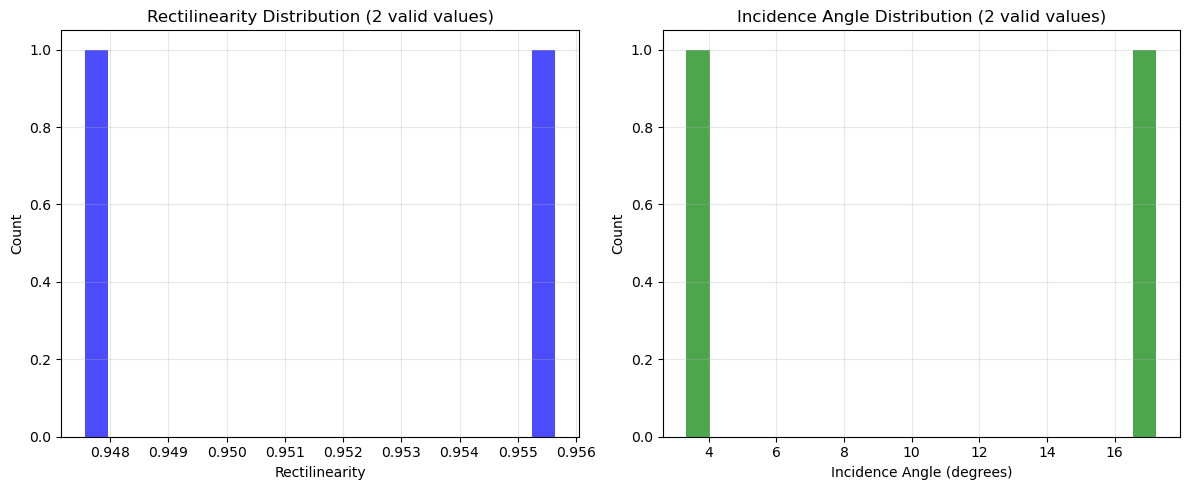


Statistics for P-wave metrics:
       rectilinearity  incidence_angle
count        2.000000         2.000000
mean         0.951604        10.286668
std          0.005712         9.830003
min          0.947564         3.335806
25%          0.949584         6.811237
50%          0.951604        10.286668
75%          0.953623        13.762099
max          0.955643        17.237530


In [8]:
# Diagnostic function to understand the relationship between catalog and stream
def diagnose_stream_catalog_mismatch(stream, catalog, max_events_to_check=5):
    """
    Diagnose why P-wave metrics fail for events after the first one.
    """
    print("DIAGNOSTIC: Stream vs Catalog Analysis")
    print("="*60)
    
    for i, (idx, event) in enumerate(catalog.head(max_events_to_check).iterrows()):
        event_time = UTCDateTime(event['datetime'])
        station_id = event['station_id']
        p_arrival_time = event['p_arrival_time']
        
        print(f"\nEvent {i+1}: {event_time}, Station: {station_id}")
        print(f"  P-arrival: {p_arrival_time} seconds after event time")
        
        if pd.notna(p_arrival_time):
            p_pick_time = event_time + float(p_arrival_time)
            window_start = p_pick_time - 0.02
            window_end = p_pick_time + 0.1
            
            print(f"  P-pick time: {p_pick_time}")
            print(f"  Required window: {window_start} to {window_end}")
            
            # Check what traces exist for this station
            st_station = stream.select(station=station_id)
            print(f"  Available traces for {station_id}: {len(st_station)}")
            
            components_found = []
            window_coverage = []
            
            for tr in st_station:
                component = tr.stats.channel[-1]
                covers_window = (tr.stats.starttime <= window_start and 
                               tr.stats.endtime >= window_end)
                
                components_found.append(component)
                window_coverage.append(covers_window)
                
                print(f"    {tr.stats.channel}: {tr.stats.starttime} to {tr.stats.endtime}")
                print(f"      Covers P-window: {covers_window}")
            
            # Summary for this event
            has_zne = 'Z' in components_found and ('N' in components_found or '1' in components_found) and ('E' in components_found or '2' in components_found)
            all_cover_window = all(window_coverage) and len(window_coverage) >= 3
            
            print(f"  Has Z,N,E components: {has_zne}")
            print(f"  All traces cover P-window: {all_cover_window}")
            print(f"  Should succeed: {has_zne and all_cover_window}")
        else:
            print(f"  ERROR: Missing P-arrival time")

# Run the diagnostic
diagnose_stream_catalog_mismatch(st, catalog)

# Now examine the results after processing
print(f"\n{'='*60}")
print("RESULTS AFTER PROCESSING")
print(f"{'='*60}")

print("Checking results:")
print(f"Shape of catalog: {catalog.shape}")
print(f"Number of valid rectilinearity values: {catalog['rectilinearity'].notna().sum()}")
print(f"Number of valid incidence angle values: {catalog['incidence_angle'].notna().sum()}")

# Show which events succeeded and failed
print(f"\nEvent-by-event success status:")
for i, (idx, event) in enumerate(catalog.head(10).iterrows()):
    rect_valid = not pd.isna(event['rectilinearity'])
    angle_valid = not pd.isna(event['incidence_angle'])
    status = "✓" if (rect_valid and angle_valid) else "✗"
    
    print(f"  Event {i+1}: {status} (rect: {'✓' if rect_valid else '✗'}, angle: {'✓' if angle_valid else '✗'})")

# Inspect first few rows
print("\nFirst few rows of catalog:")
display(catalog[['event_id', 'station_id', 'datetime', 'rectilinearity', 'incidence_angle']].head())

# Display a histogram of the metrics if we have any valid values
valid_rect_count = catalog['rectilinearity'].notna().sum()
valid_angle_count = catalog['incidence_angle'].notna().sum()

if valid_rect_count > 0 or valid_angle_count > 0:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    if valid_rect_count > 0:
        plt.hist(catalog['rectilinearity'].dropna(), bins=20, color='blue', alpha=0.7)
        plt.title(f'Rectilinearity Distribution ({valid_rect_count} valid values)')
    else:
        plt.text(0.5, 0.5, 'No valid rectilinearity values', ha='center', va='center')
        plt.title('Rectilinearity Distribution (No valid values)')
    plt.xlabel('Rectilinearity')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    if valid_angle_count > 0:
        plt.hist(catalog['incidence_angle'].dropna(), bins=20, color='green', alpha=0.7)
        plt.title(f'Incidence Angle Distribution ({valid_angle_count} valid values)')
    else:
        plt.text(0.5, 0.5, 'No valid incidence angle values', ha='center', va='center')
        plt.title('Incidence Angle Distribution (No valid values)')
    plt.xlabel('Incidence Angle (degrees)')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No valid metrics to plot - all calculations failed")

# Statistics (only if we have valid data)
if valid_rect_count > 0 or valid_angle_count > 0:
    print("\nStatistics for P-wave metrics:")
    print(catalog[['rectilinearity', 'incidence_angle']].describe())
else:
    print("\nNo valid P-wave metrics calculated - check diagnostic output above")

In [9]:
# Filter catalog based on rectilinearity and angle of incidence
rectilinearity_threshold = 0.7
angle_of_incidence_threshold = 30.0

# Apply filters
filtered_catalog = catalog[
    (catalog['rectilinearity'] >= rectilinearity_threshold) &
    (catalog['incidence_angle'] <= angle_of_incidence_threshold)
].reset_index(drop=True)

# Print results
print(f"Original catalog size: {len(catalog)} events")
print(f"Filtered catalog size: {len(filtered_catalog)} events")
print(f"Removed {len(catalog) - len(filtered_catalog)} events")

# Update the catalog for further analysis
catalog = filtered_catalog.copy()

# Show a sample of the filtered catalog
display(catalog.head())

Original catalog size: 2 events
Filtered catalog size: 2 events
Removed 0 events


,event_id,year,lat,lon,depth,magnitude,datetime,station_id,station_lat,station_lon,...,endtime,p_arrival_time,s_arrival_time,rectilinearity,incidence_angle,snr_e,snr_n,snr_horizontal,extended_start,s_arrival
0,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC1,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.955643,3.335806,5.091918,6.194694,5.643306,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z
1,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC2,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.947564,17.237530,4.070781,0.760443,2.415612,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z


## P-wave Quality Metrics Completed

P-wave rectilinearity and incidence angle calculations have been completed using the improved stream organization method in the previous cells. The catalog now contains the calculated metrics for quality filtering before shear-wave splitting analysis.

### Explanation of P-wave Quality Filtering

The code above calculates two important quality metrics for each event using P-wave polarization analysis:

1. **Rectilinearity**: Measures how linear the particle motion is during the P-wave arrival. Higher values (closer to 1.0) indicate more reliable data with less scattered energy. We filter for rectilinearity > 0.7.

2. **True Incidence Angle**: Calculated from the polarization of the P-wave rather than geometric approximation. This gives the actual angle at which the wave impinges on the station, accounting for velocity structure. We filter for incidence angle < 30°.

These metrics serve as quality control filters before shear-wave splitting analysis:
- High rectilinearity ensures clear P-wave arrivals with minimal noise and scattering
- Small incidence angles (near-vertical arrivals) reduce S-wave conversion effects at layer boundaries
- Together, they provide more reliable data for shear-wave splitting measurements

The filtered catalog contains only events that meet both criteria, resulting in higher quality splitting measurements.

In [10]:
catalog

,event_id,year,lat,lon,depth,magnitude,datetime,station_id,station_lat,station_lon,...,endtime,p_arrival_time,s_arrival_time,rectilinearity,incidence_angle,snr_e,snr_n,snr_horizontal,extended_start,s_arrival
0,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC1,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.955643,3.335806,5.091918,6.194694,5.643306,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z
1,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC2,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.947564,17.237530,4.070781,0.760443,2.415612,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z


In [11]:
# Calculate Signal-to-Noise Ratio (SNR) for S-wave windows
import numpy as np

def compute_snr_for_event(event_stream, event_row, component='E'):
    """Calculate SNR for a specific component using S-wave windows."""
    try:
        # Debug: Check if S-arrival time exists
        if 's_arrival_time' not in event_row or pd.isna(event_row['s_arrival_time']):
            print(f"  No S-arrival time for {component}")
            return np.nan
        
        event_time = UTCDateTime(event_row['datetime'])
        s_pick = event_time + float(event_row['s_arrival_time'])
        print(f"  S-pick time: {s_pick}")
        
        # Get S-P delay for noise window sizing
        sp_delay = None
        if 'p_arrival_time' in event_row and not pd.isna(event_row['p_arrival_time']):
            sp_delay = event_row['s_arrival_time'] - event_row['p_arrival_time']
            print(f"  S-P delay: {sp_delay}")
        
        # Find component trace
        trace = None
        for tr in event_stream:
            if tr.stats.channel[-1].upper() == component.upper():
                trace = tr.copy()
                break
        
        if trace is None:
            print(f"  No {component} component trace found")
            return np.nan
        
        print(f"  Found {component} trace: {trace.stats.starttime} to {trace.stats.endtime}")
        
        # Apply filtering
        trace.filter("bandpass", freqmin=5, freqmax=40)
        trace.taper(type="hann", max_percentage=0.05)
        
        # Define time windows
        noise_window = min(0.4, sp_delay / 2) if sp_delay else 0.4
        signal_window = 0.2
        
        noise_start = s_pick - noise_window
        noise_end = s_pick
        signal_start = s_pick
        signal_end = s_pick + signal_window
        
        print(f"  Noise window: {noise_start} to {noise_end}")
        print(f"  Signal window: {signal_start} to {signal_end}")
        
        # Check trace coverage
        if (trace.stats.starttime > noise_start or trace.stats.endtime < signal_end):
            print(f"  Trace doesn't cover required windows")
            print(f"  Trace: {trace.stats.starttime} to {trace.stats.endtime}")
            return np.nan
        
        # Extract data
        noise_data = trace.slice(noise_start, noise_end).data
        signal_data = trace.slice(signal_start, signal_end).data
        
        print(f"  Noise data points: {len(noise_data)}")
        print(f"  Signal data points: {len(signal_data)}")
        
        if len(noise_data) == 0 or len(signal_data) == 0:
            print(f"  Empty noise or signal window")
            return np.nan
        
        # Calculate SNR
        noise_rms = np.sqrt(np.mean(noise_data**2))
        signal_rms = np.sqrt(np.mean(signal_data**2))
        
        print(f"  Noise RMS: {noise_rms}")
        print(f"  Signal RMS: {signal_rms}")
        
        if noise_rms == 0:
            print(f"  Zero noise level")
            return np.nan
        
        snr = signal_rms / noise_rms
        print(f"  SNR: {snr}")
        return float(snr)
        
    except Exception as e:
        print(f"  Error calculating SNR for {component}: {e}")
        return np.nan

def calculate_snr_for_catalog(event_streams, catalog):
    """Calculate SNR for all events in catalog."""
    updated_catalog = catalog.copy()
    
    # Add SNR columns
    for col in ['snr_e', 'snr_n', 'snr_horizontal']:
        if col not in updated_catalog.columns:
            updated_catalog[col] = np.nan
    
    print(f"Calculating SNR for {len(catalog)} events...")
    
    for i, (idx, event) in enumerate(updated_catalog.iterrows()):
        print(f"\n[Event {i+1}] ID: {event.get('event_id', idx)}")
        
        event_stream = event_streams.get(idx)
        if event_stream is None:
            print(f"  No stream data for this event")
            continue
        
        print(f"  Stream has {len(event_stream)} traces")
        
        # Calculate SNR for both horizontal components
        snr_e = compute_snr_for_event(event_stream, event, 'E')
        snr_n = compute_snr_for_event(event_stream, event, 'N')
        
        # Calculate horizontal average
        if not np.isnan(snr_e) and not np.isnan(snr_n):
            snr_horizontal = (snr_e + snr_n) / 2
        elif not np.isnan(snr_e):
            snr_horizontal = snr_e
        elif not np.isnan(snr_n):
            snr_horizontal = snr_n
        else:
            snr_horizontal = np.nan
        
        # Update catalog
        updated_catalog.at[idx, 'snr_e'] = snr_e
        updated_catalog.at[idx, 'snr_n'] = snr_n
        updated_catalog.at[idx, 'snr_horizontal'] = snr_horizontal
        
        # Only process first few events for debugging
        if i >= 2:  # Stop after 3 events for debugging
            break
    
    return updated_catalog

# Calculate SNR with debugging
catalog = calculate_snr_for_catalog(event_streams, catalog)


Calculating SNR for 2 events...

[Event 1] ID: 0.072
  Stream has 6 traces
  S-pick time: 2015-01-22T02:59:41.655000Z
  S-P delay: 0.38500000000000006
  Found E trace: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
  Noise window: 2015-01-22T02:59:41.462500Z to 2015-01-22T02:59:41.655000Z
  Signal window: 2015-01-22T02:59:41.655000Z to 2015-01-22T02:59:41.855000Z
  Noise data points: 39
  Signal data points: 41
  Noise RMS: 158.34100088604913
  Signal RMS: 806.2593364652195
  SNR: 5.091917645799447
  S-pick time: 2015-01-22T02:59:41.655000Z
  S-P delay: 0.38500000000000006
  Found N trace: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
  Noise window: 2015-01-22T02:59:41.462500Z to 2015-01-22T02:59:41.655000Z
  Signal window: 2015-01-22T02:59:41.655000Z to 2015-01-22T02:59:41.855000Z
  Noise data points: 39
  Signal data points: 41
  Noise RMS: 127.35182275705189
  Signal RMS: 788.9056265289602
  SNR: 6.194694425645948

[Event 2] ID: 0.072
  Stream has 8 traces


In [12]:
# Debug: Test SNR calculation on one event
catalog = calculate_snr_for_catalog(event_streams, catalog)

Calculating SNR for 2 events...

[Event 1] ID: 0.072
  Stream has 6 traces
  S-pick time: 2015-01-22T02:59:41.655000Z
  S-P delay: 0.38500000000000006
  Found E trace: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
  Noise window: 2015-01-22T02:59:41.462500Z to 2015-01-22T02:59:41.655000Z
  Signal window: 2015-01-22T02:59:41.655000Z to 2015-01-22T02:59:41.855000Z
  Noise data points: 39
  Signal data points: 41
  Noise RMS: 158.34100088604913
  Signal RMS: 806.2593364652195
  SNR: 5.091917645799447
  S-pick time: 2015-01-22T02:59:41.655000Z
  S-P delay: 0.38500000000000006
  Found N trace: 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
  Noise window: 2015-01-22T02:59:41.462500Z to 2015-01-22T02:59:41.655000Z
  Signal window: 2015-01-22T02:59:41.655000Z to 2015-01-22T02:59:41.855000Z
  Noise data points: 39
  Signal data points: 41
  Noise RMS: 127.35182275705189
  Signal RMS: 788.9056265289602
  SNR: 6.194694425645948

[Event 2] ID: 0.072
  Stream has 8 traces


In [13]:
catalog

,event_id,year,lat,lon,depth,magnitude,datetime,station_id,station_lat,station_lon,...,endtime,p_arrival_time,s_arrival_time,rectilinearity,incidence_angle,snr_e,snr_n,snr_horizontal,extended_start,s_arrival
0,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC1,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.955643,3.335806,5.091918,6.194694,5.643306,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z
1,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC2,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.947564,17.237530,4.070781,0.760443,2.415612,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z


In [14]:
# Filter by SNR threshold
snr_threshold = 2.0
catalog = catalog[
    (catalog['snr_horizontal'] >= snr_threshold) & 
    (catalog['snr_horizontal'].notna())
].reset_index(drop=True)

print(f"Catalog filtered by SNR ≥ {snr_threshold}: {len(catalog)} events remaining")

Catalog filtered by SNR ≥ 2.0: 2 events remaining


In [15]:
# Ensure the catalog has datetime columns formatted correctly for ObsPy
if 'datetime' not in catalog.columns:
    if all(col in catalog.columns for col in ['year', 'month', 'day', 'hour', 'minute', 'second']):
        print("Creating datetime column from year, month, day, hour, minute, second...")
        catalog['datetime'] = catalog.apply(
            lambda row: f"{row['year']}-{row['month']:02d}-{row['day']:02d}T{row['hour']:02d}:{row['minute']:02d}:{row['second']:04.1f}Z", 
            axis=1
        )
        print("Datetime column created successfully")
    else:
        print("Warning: Cannot create datetime column due to missing time components")
else:
    print("Datetime column already exists in catalog")
    
# Add S-wave arrival time if not already present
if 's_arrival_time' not in catalog.columns:
    print("Creating S-arrival time column based on P-arrival time...")
    # Estimate S-wave arrival as 1.7 times P-wave arrival (rough Vp/Vs approximation)
    # This is a simplification - you may want to use actual S-wave picks if available
    catalog['s_arrival_time'] = catalog['p_arrival_time'] * 1.7
    print("S-arrival time column created")
else:
    print("S-arrival time column already exists in catalog")
    
# Calculate absolute S-wave arrival time
catalog['s_arrival'] = catalog['datetime'].apply(
    lambda dt: UTCDateTime(dt)
) + catalog['s_arrival_time']

print("Processing complete. Catalog ready for analysis.")
display(catalog[['event_id', 'station_id', 'datetime', 'p_arrival_time', 's_arrival_time', 's_arrival']].head())

Datetime column already exists in catalog
S-arrival time column already exists in catalog
Processing complete. Catalog ready for analysis.


,event_id,station_id,datetime,p_arrival_time,s_arrival_time,s_arrival
0,0.072,AXEC1,2015-01-22 02:59:40.845,0.425,0.81,2015-01-22T02:59:41.655000Z
1,0.072,AXEC2,2015-01-22 02:59:40.845,0.425,0.81,2015-01-22T02:59:41.655000Z


In [16]:
def prepare_stream_for_splitting(stream, station_name, start_time=None, window_length=15):
    """
    Prepare an ObsPy stream for shear-wave splitting analysis by filtering and selecting specific station data.
    
    Parameters:
    -----------
    stream : obspy.Stream
        The raw seismic stream object
    station_name : str
        Name of the station to select
    start_time : obspy.UTCDateTime, optional
        Start time for trimming. If None, uses stream's start time.
    window_length : float, optional
        Length of time window in seconds
    
    Returns:
    --------
    obspy.Stream
        Filtered and trimmed stream containing only the selected station data
    """
    # Select data for specific station
    st_filtered = stream.select(station=station_name)
    
    if len(st_filtered) == 0:
        print(f"No data found for station {station_name}")
        return None
    
    # Apply highpass filter to remove low-frequency noise
    st_filtered = st_filtered.copy()
    st_filtered.filter("highpass", freq=10.0)
    
    # Trim to specified time window
    if start_time is None:
        start_time = st_filtered[0].stats.starttime
    
    st_filtered = st_filtered.trim(starttime=start_time,
                                  endtime=start_time + window_length)
    
    # Display information about the prepared stream
    components = [tr.stats.channel[-1] for tr in st_filtered]
    print(f"Prepared stream contains {len(st_filtered)} traces for station {station_name}")
    print(f"Components: {components}")
    
    return st_filtered

## Dynamic Analysis Parameters for Shear-Wave Splitting

The following functions implement dynamic analysis parameter estimation using spectral analysis to optimize splitting analysis windows and filtering based on the dominant period of each event.

In [17]:
import numpy as np
from obspy.signal.spectral_estimation import PPSD

# Check for optional mtspec library
try:
    from mtspec import mtspec
    MTSPEC_AVAILABLE = True
except ImportError:
    MTSPEC_AVAILABLE = False
    print("mtspec not available, using ObsPy PPSD method")

def estimate_dominant_period(trace, method='obspy'):
    """
    Estimate the dominant period of a seismic trace using spectral analysis.
    
    Parameters:
    -----------
    trace : obspy.Trace
        Input seismic trace
    method : str
        'obspy' for ObsPy PPSD or 'mtspec' for multitaper method
        
    Returns:
    --------
    float
        Dominant period in seconds
    """
    if trace is None or len(trace.data) == 0:
        return np.nan
    
    # Preprocess trace
    trace_copy = trace.copy()
    trace_copy.detrend("linear")
    trace_copy.taper(type="hann", max_percentage=0.05)
    
    try:
        if method == 'mtspec' and MTSPEC_AVAILABLE:
            # Multitaper spectral estimation
            spec, freq = mtspec(
                data=trace_copy.data, 
                delta=trace_copy.stats.delta, 
                time_bandwidth=4, 
                number_of_tapers=7
            )
            dominant_freq = freq[np.argmax(spec)]
        else:
            # ObsPy PPSD method (fallback)
            df = trace_copy.stats.sampling_rate
            nfft = 2 ** int(np.ceil(np.log2(len(trace_copy.data))))
            freq, power = PPSD(trace_copy.data, NFFT=nfft, Fs=df, method="multitaper")
            dominant_freq = freq[np.argmax(power)]
        
        # Convert to dominant period
        t_dom = 1.0 / dominant_freq if dominant_freq > 0 else np.nan
        return t_dom
    
    except Exception as e:
        print(f"Error estimating dominant period: {e}")
        return np.nan

def calculate_dynamic_parameters(event_stream, event_data, s_arrival_buffer=1.0):
    """
    Calculate dynamic analysis parameters for an event using spectral analysis.
    
    Parameters:
    -----------
    event_stream : obspy.Stream
        Stream containing event data
    event_data : pandas.Series
        Event metadata
    s_arrival_buffer : float
        Buffer around S-arrival for analysis window (seconds)
        
    Returns:
    --------
    dict
        Dictionary containing dynamic parameters
    """
    try:
        # Get S-arrival time
        event_time = UTCDateTime(event_data['datetime'])
        s_pick = event_time + float(event_data['s_arrival_time'])
        
        # Extract traces around S-arrival for spectral analysis
        analysis_start = s_pick - s_arrival_buffer
        analysis_end = s_pick + s_arrival_buffer
        
        # Get horizontal components for analysis
        trace_e = None
        trace_n = None
        
        for tr in event_stream:
            component = tr.stats.channel[-1].upper()
            if component in ['E', '2']:
                trace_e = tr.slice(analysis_start, analysis_end)
            elif component in ['N', '1']:
                trace_n = tr.slice(analysis_start, analysis_end)
        
        # Calculate dominant periods for both horizontal components
        t_dom_e = estimate_dominant_period(trace_e) if trace_e and len(trace_e.data) > 10 else np.nan
        t_dom_n = estimate_dominant_period(trace_n) if trace_n and len(trace_n.data) > 10 else np.nan
        
        # Use average or the valid one
        if not np.isnan(t_dom_e) and not np.isnan(t_dom_n):
            t_dom = (t_dom_e + t_dom_n) / 2
        elif not np.isnan(t_dom_e):
            t_dom = t_dom_e
        elif not np.isnan(t_dom_n):
            t_dom = t_dom_n
        else:
            t_dom = 0.1  # Default fallback (10 Hz dominant frequency)
        
        # Calculate dynamic window parameters
        # Window should be several dominant periods long, but within reasonable bounds
        dynamic_window_length = max(0.5, min(2.0, 4 * t_dom))  # 4 periods, but between 0.5-2.0s
        
        # Calculate optimal filter frequencies
        # Center frequency around 1/T_dom, with reasonable bandwidth
        center_freq = 1.0 / t_dom
        freq_min = max(1.0, center_freq * 0.5)  # Lower bound at least 1 Hz
        freq_max = min(50.0, center_freq * 2.5)  # Upper bound at most 50 Hz
        
        return {
            't_dom': t_dom,
            't_dom_e': t_dom_e,
            't_dom_n': t_dom_n,
            'dynamic_window_length': dynamic_window_length,
            'optimal_freq_min': freq_min,
            'optimal_freq_max': freq_max,
            'center_frequency': center_freq
        }
        
    except Exception as e:
        print(f"Error calculating dynamic parameters: {e}")
        return {
            't_dom': 0.1,
            'dynamic_window_length': 1.0,
            'optimal_freq_min': 5.0,
            'optimal_freq_max': 40.0,
            'center_frequency': 10.0
        }

mtspec not available, using ObsPy PPSD method


In [18]:
def create_splitting_analysis(stream, event_data, use_dynamic_params=True):
    """
    Enhanced splitting analysis creation with dynamic parameters.
    
    Parameters:
    -----------
    stream : obspy.Stream
        Prepared stream containing seismic data for a specific station
    event_data : pandas.Series
        Event data from catalog containing necessary metadata
    use_dynamic_params : bool
        Whether to use dynamic windowing and filtering based on spectral analysis
        
    Returns:
    --------
    swspy.splitting object
        Splitting object ready for analysis with optimized parameters
    """
    # Calculate dynamic parameters if requested
    if use_dynamic_params:
        dynamic_params = calculate_dynamic_parameters(stream, event_data)
        print(f"Dynamic parameters calculated:")
        print(f"  Dominant period: {dynamic_params['t_dom']:.3f} s")
        print(f"  Dynamic window length: {dynamic_params['dynamic_window_length']:.3f} s")
        print(f"  Optimal frequency range: {dynamic_params['optimal_freq_min']:.1f}-{dynamic_params['optimal_freq_max']:.1f} Hz")
    else:
        # Use default parameters
        dynamic_params = {
            'dynamic_window_length': 1.0,
            'optimal_freq_min': 5.0,
            'optimal_freq_max': 40.0,
            't_dom': 0.1
        }
    
    # Apply optimal filtering to the stream
    stream_filtered = stream.copy()
    stream_filtered.filter(
        "bandpass", 
        freqmin=dynamic_params['optimal_freq_min'], 
        freqmax=dynamic_params['optimal_freq_max']
    )
    
    # Create splitting object with SWSPy
    splitting_event = swspy.splitting.create_splitting_object(
        stream_filtered, 
        stations_in=[event_data['station_id']],
        back_azis_all_stations=[event_data['back_azimuth']],
        receiver_inc_angles_all_stations=[event_data['incidence_angle']],
        S_phase_arrival_times=[event_data['s_arrival']]
    )
    
    # Set dynamic analysis parameters
    if use_dynamic_params:
        window_half_length = dynamic_params['dynamic_window_length'] / 2
        
        splitting_event.overall_win_start_pre_fast_S_pick = window_half_length
        splitting_event.win_S_pick_tolerance = min(0.1, dynamic_params['t_dom'] / 4)  # Quarter period tolerance
        splitting_event.overall_win_start_post_fast_S_pick = window_half_length
        splitting_event.rotate_step_deg = 1.0
        splitting_event.max_t_shift_s = min(0.2, dynamic_params['t_dom'])  # Max shift = dominant period
        splitting_event.n_win = max(5, int(20 / dynamic_params['t_dom']))  # More windows for higher frequency signals
    else:
        # Use default parameters
        splitting_event.overall_win_start_pre_fast_S_pick = 0.3
        splitting_event.win_S_pick_tolerance = 0.1
        splitting_event.overall_win_start_post_fast_S_pick = 0.2
        splitting_event.rotate_step_deg = 1.0
        splitting_event.max_t_shift_s = 0.1
        splitting_event.n_win = 10
    
    # Store dynamic parameters in the splitting object for reference
    if use_dynamic_params:
        splitting_event.dynamic_params = dynamic_params
    
    return splitting_event

## 4. Extract Sample Data for Analysis

In [19]:
# Select a sample of 100 events for analysis
# Prioritize events from one station (e.g. AXAS1) for consistency
sample_size = min(100, len(catalog))
print(f"Creating sample of {sample_size} events for analysis...")

# Check if we have station_id column
if 'station_id' in catalog.columns:
    # Count events per station
    station_counts = catalog['station_id'].value_counts()
    print("\nEvents per station:")
    print(station_counts)
    
    # Create a focused sample with preference for one station
    preferred_station = 'AXAS1'  # Change to your preferred station
    station_events = catalog[catalog['station_id'] == preferred_station]
    
    if len(station_events) >= sample_size:
        # If we have enough events from the preferred station, use those
        sample_catalog = station_events.head(sample_size)
        print(f"Using {sample_size} events from station {preferred_station}")
    else:
        # Otherwise, take all events from preferred station and fill with others
        print(f"Taking all {len(station_events)} events from {preferred_station} and " + 
              f"adding {sample_size - len(station_events)} events from other stations")
        other_events = catalog[catalog['station_id'] != preferred_station]
        sample_catalog = pd.concat([station_events, 
                                   other_events.head(sample_size - len(station_events))])
else:
    # If no station_id column, just take the first 100 events
    sample_catalog = catalog.head(sample_size)
    print(f"Using first {sample_size} events from catalog (no station filtering)")

# Reset the index
sample_catalog = sample_catalog.reset_index(drop=True)

print(f"Sample catalog contains {len(sample_catalog)} events")
print(f"Date range: {pd.to_datetime(sample_catalog['datetime']).min()} to {pd.to_datetime(sample_catalog['datetime']).max()}")

# Display the first few rows of the sample catalog
display(sample_catalog[['event_id', 'station_id', 'datetime', 'lat', 'lon', 'depth', 'back_azimuth', 'angle_of_incidence']].head())

Creating sample of 2 events for analysis...

Events per station:
station_id
AXEC1    1
AXEC2    1
Name: count, dtype: int64
Taking all 0 events from AXAS1 and adding 2 events from other stations
Sample catalog contains 2 events
Date range: 2015-01-22 02:59:40.845000 to 2015-01-22 02:59:40.845000


,event_id,station_id,datetime,lat,lon,depth,back_azimuth,angle_of_incidence
0,0.072,AXEC1,2015-01-22 02:59:40.845,45.94606,-129.98662,1.305,226.653013,27.14788
1,0.072,AXEC2,2015-01-22 02:59:40.845,45.94606,-129.98662,1.305,226.653013,27.14788


In [20]:
# Save the sample catalog for reference
sample_catalog_file = '../data/old_sample_catalog_for_splitting_100.csv'
sample_catalog.to_csv(sample_catalog_file, index=False)
print(f"Sample catalog saved to: {sample_catalog_file}")

# Prepare datetime column for waveform extraction
# Ensure datetime and endtime columns exist for get_all_traces
if not 'endtime' in sample_catalog.columns:
    sample_catalog['endtime'] = sample_catalog['datetime'].apply(
        lambda dt: UTCDateTime(dt) + 15
    )
    print("Created endtime column as datetime + 15 seconds")

# Create a MSEED file containing waveform data for all sample events
mseed_filename = 'old_catalog_waveforms'
print(f"Retrieving waveform data for {len(sample_catalog)} events...")
print("This may take a while depending on the number of events and data availability.")
print("(If you've already downloaded the data, you can skip this step)")

# Call get_all_traces to retrieve waveforms for all events in the sample catalog
# Note: Uncomment this when you're ready to retrieve the data
# get_all_traces(sample_catalog, mseed_filename, 'datetime', 'endtime')
print(f"Waveform data would be saved to: {mseed_filename}.mseed")

# For demonstration purposes, assume the file has already been created
print("\nNote: The get_all_traces function call is currently commented out.")
print("If you need to retrieve new data, uncomment the function call above.")
print("For now, we'll assume the data is available in 'sample_waveforms.mseed'")
print("If you've already run this notebook before, you should have a file called 'splitting_analysis_sample.mseed'")

Sample catalog saved to: ../data/old_sample_catalog_for_splitting_100.csv
Retrieving waveform data for 2 events...
This may take a while depending on the number of events and data availability.
(If you've already downloaded the data, you can skip this step)
Waveform data would be saved to: old_catalog_waveforms.mseed

Note: The get_all_traces function call is currently commented out.
If you need to retrieve new data, uncomment the function call above.
For now, we'll assume the data is available in 'sample_waveforms.mseed'
If you've already run this notebook before, you should have a file called 'splitting_analysis_sample.mseed'


In [21]:
sample_catalog

,event_id,year,lat,lon,depth,magnitude,datetime,station_id,station_lat,station_lon,...,endtime,p_arrival_time,s_arrival_time,rectilinearity,incidence_angle,snr_e,snr_n,snr_horizontal,extended_start,s_arrival
0,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC1,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.955643,3.335806,5.091918,6.194694,5.643306,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z
1,0.072,2015,45.94606,-129.98662,1.305,0.3,2015-01-22 02:59:40.845,AXEC2,45.955,-129.973,...,2015-01-22 02:59:55.845,0.425,0.81,0.947564,17.237530,4.070781,0.760443,2.415612,2015-01-22T02:59:36.845000Z,2015-01-22T02:59:41.655000Z


## 6. Visualize Seismogram for One Event

In [22]:
# Select a station for analysis (prefer AXAS1 if available)
preferred_station = 'AXAS1'

if preferred_station in stations:
    analysis_station = preferred_station
    print(f"Using preferred station: {analysis_station}")
else:
    analysis_station = stations[0]
    print(f"Preferred station not available, using: {analysis_station}")

# Get a specific event for this station from the sample catalog
station_events = sample_catalog[sample_catalog['station_id'] == analysis_station]
if len(station_events) > 1:
    event_idx = 1  # Use the second event
    event_data = station_events.iloc[event_idx]
    print(f"Selected event ID: {event_data['event_id']} at station: {event_data['station_id']}")
else:
    print(f"No events found for station {analysis_station}. Using second event in catalog.")
    event_data = sample_catalog.iloc[1]
    print(f"Selected event ID: {event_data['event_id']} at station: {event_data['station_id']}")
    analysis_station = event_data['station_id']

Using preferred station: AXAS1
No events found for station AXAS1. Using second event in catalog.
Selected event ID: 0.072 at station: AXEC2


In [23]:
event_data

event_id                                        0.072
year                                             2015
lat                                          45.94606
lon                                        -129.98662
depth                                           1.305
magnitude                                         0.3
datetime                      2015-01-22 02:59:40.845
station_id                                      AXEC2
station_lat                                    45.955
station_lon                                  -129.973
station_elev                                   -1.519
back_azimuth                               226.653013
epicentral_distance_km                       1.448093
angle_of_incidence                           27.14788
endtime                       2015-01-22 02:59:55.845
p_arrival_time                                  0.425
s_arrival_time                                   0.81
rectilinearity                               0.947564
incidence_angle             

In [24]:
event_data['p_arrival_time']

np.float64(0.425)

In [25]:
# P-wave metrics have already been calculated for all events using the improved method
# This cell shows how to extract individual event information for visualization purposes

# Get event time for this specific event
event_time = UTCDateTime(event_data['datetime'])

# Prepare stream for visualization (this is just for plotting, not for P-wave calculation)
prepared_st = prepare_stream_for_splitting(st, analysis_station, event_time)

print(f"Event information:")
print(f"  Event time: {event_time}")
print(f"  Station: {analysis_station}")
print(f"  P-wave rectilinearity: {event_data.get('rectilinearity', 'Not calculated')}")
print(f"  Incidence angle: {event_data.get('incidence_angle', 'Not calculated')}")

Prepared stream contains 8 traces for station AXEC2
Components: ['E', 'E', 'N', 'N', 'Z', 'Z', 'H', 'H']
Event information:
  Event time: 2015-01-22T02:59:40.845000Z
  Station: AXEC2
  P-wave rectilinearity: 0.9475643233495854
  Incidence angle: 17.237530136775245


In [26]:
event_data

event_id                                        0.072
year                                             2015
lat                                          45.94606
lon                                        -129.98662
depth                                           1.305
magnitude                                         0.3
datetime                      2015-01-22 02:59:40.845
station_id                                      AXEC2
station_lat                                    45.955
station_lon                                  -129.973
station_elev                                   -1.519
back_azimuth                               226.653013
epicentral_distance_km                       1.448093
angle_of_incidence                           27.14788
endtime                       2015-01-22 02:59:55.845
p_arrival_time                                  0.425
s_arrival_time                                   0.81
rectilinearity                               0.947564
incidence_angle             

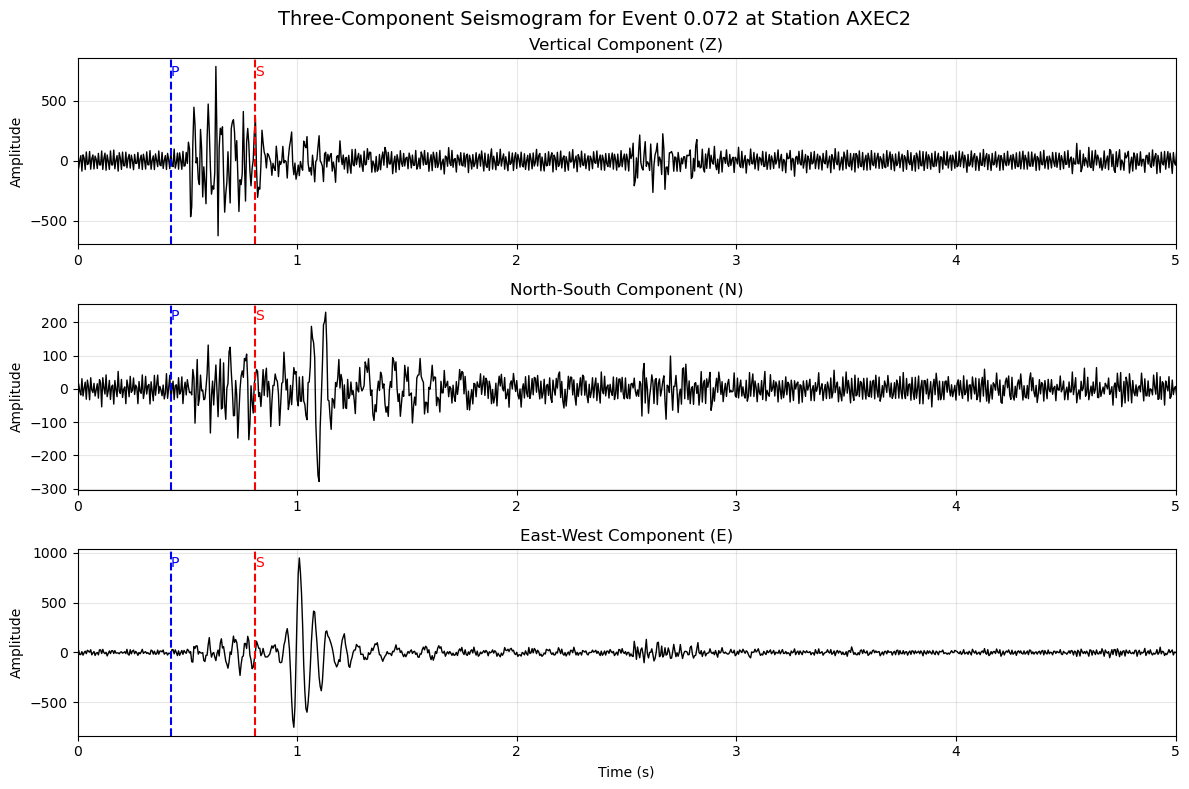

In [ ]:
# Prepare the stream for the selected event

# If preparation failed, try a different approach
if prepared_st is None or len(prepared_st) < 3:  # Need at least 3 components
    print("Could not find appropriate traces for this event/station. Trying a different approach...")
    
    # Select all traces for this station
    st_station = st.select(station=analysis_station)
    
    if len(st_station) > 0:
        # Find traces that might contain the event
        event_traces = []
        for tr in st_station:
            if tr.stats.starttime <= event_time and tr.stats.endtime >= event_time:
                event_traces.append(tr)
        
        if len(event_traces) > 0:
            print(f"Found {len(event_traces)} traces that contain the event time")
            prepared_st = obspy.Stream(event_traces)
            prepared_st = prepared_st.trim(starttime=event_time, endtime=event_time + 8)
            prepared_st.taper()
            prepared_st.filter("bandpass", lowfreq=4.0, highfreq=50.0)
        else:
            print("No traces found containing the event time")
            # Use the first available set of traces for this station
            unique_starttimes = sorted(set(tr.stats.starttime for tr in st_station))
            if len(unique_starttimes) > 0:
                start_time = unique_starttimes[0]
                prepared_st = st_station.select(starttime=start_time)
                prepared_st = prepared_st.trim(starttime=start_time, endtime=start_time + 8)
                prepared_st.filter("bandpass", lowfreq=5.0, highfreq=40.0)
                print(f"Using traces starting at {start_time}")
            else:
                print("No suitable traces found for this station")
    else:
        print(f"No traces found for station {analysis_station}")

# Check if we have a valid stream for analysis
if prepared_st and len(prepared_st) > 0:
    # Plot the three components (Z, N, E) of the seismogram
    plt.figure(figsize=(12, 8))
    
    components = {'Z': 'Vertical', 'N': 'North-South', 'E': 'East-West'}
    colors = {'Z': 'black', 'N': 'black', 'E': 'black'}
    
    for i, comp in enumerate(components.keys(), 1):
        comp_trace = prepared_st.select(component=comp)
        
        if len(comp_trace) > 0:
            tr = comp_trace[0]
            plt.subplot(3, 1, i)
            
            # Plot the trace
            times = tr.times()
            plt.plot(times, tr.data, color=colors.get(comp, 'green'), linewidth=1)
            plt.xlim(0,5)
            
            # Add P-arrival marker if available
            if hasattr(event_data, 'p_arrival_time'):
                p_pick_time = event_data['p_arrival_time']
                if 0 <= p_pick_time <= tr.stats.endtime - tr.stats.starttime:
                    plt.axvline(x=p_pick_time, color='blue', linestyle='--', label='P-arrival')
                    plt.text(p_pick_time, tr.data.max() * 0.9, 'P', color='blue')

            # Add S-arrival marker if available
            if hasattr(event_data, 's_arrival_time'):
                s_pick_time = event_data['s_arrival_time']
                if 0 <= s_pick_time <= tr.stats.endtime - tr.stats.starttime:
                    plt.axvline(x=s_pick_time, color='red', linestyle='--', label='S-arrival')
                    plt.text(s_pick_time, tr.data.max() * 0.9, 'S', color='red')
            
            plt.title(f"{components[comp]} Component ({comp})")
            plt.ylabel("Amplitude")
            if i == 3:  # Only add x-label to bottom plot
                plt.xlabel("Time (s)")
                plt.xlim(0, 5)
            plt.grid(True, alpha=0.3)
        else:
            plt.subplot(3, 1, i)
            plt.xlim(0, 5)
            plt.text(0.5, 0.5, f"No {components[comp]} component data available", 
                    horizontalalignment='center', verticalalignment='center')
            plt.axis('off')
    
    plt.suptitle(f"Three-Component Seismogram for Event {event_data['event_id']} at Station {analysis_station}", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("No suitable data available for plotting")
    print("You may need to download the data using get_all_traces or select a different event")

In [28]:
prepared_st

8 Trace(s) in Stream:
OO.AXEC2..HHE | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHE | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHN | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHN | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHZ | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHZ | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HDH | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HDH | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples

In [29]:

prepared_st = prepared_st.remove(prepared_st[7])
prepared_st = prepared_st.remove(prepared_st[6])
prepared_st = prepared_st.remove(prepared_st[5])
prepared_st = prepared_st.remove(prepared_st[3])
prepared_st = prepared_st.remove(prepared_st[1])

In [30]:
prepared_st

3 Trace(s) in Stream:
OO.AXEC2..HHE | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHN | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples
OO.AXEC2..HHZ | 2015-01-22T02:59:40.845000Z - 2015-01-22T02:59:55.845000Z | 200.0 Hz, 3001 samples

## 7. Create Splitting Object with SWSPy and Perform Analysis

Step 1: Creating splitting object...
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Dynamic parameters calculated:
  Dominant period: 0.100 s
  Dynamic window length: 0.500 s
  Optimal frequency range: 5.0-25.0 Hz

Step 2: Performing shear-wave splitting analysis...

Step 3: Plotting results...


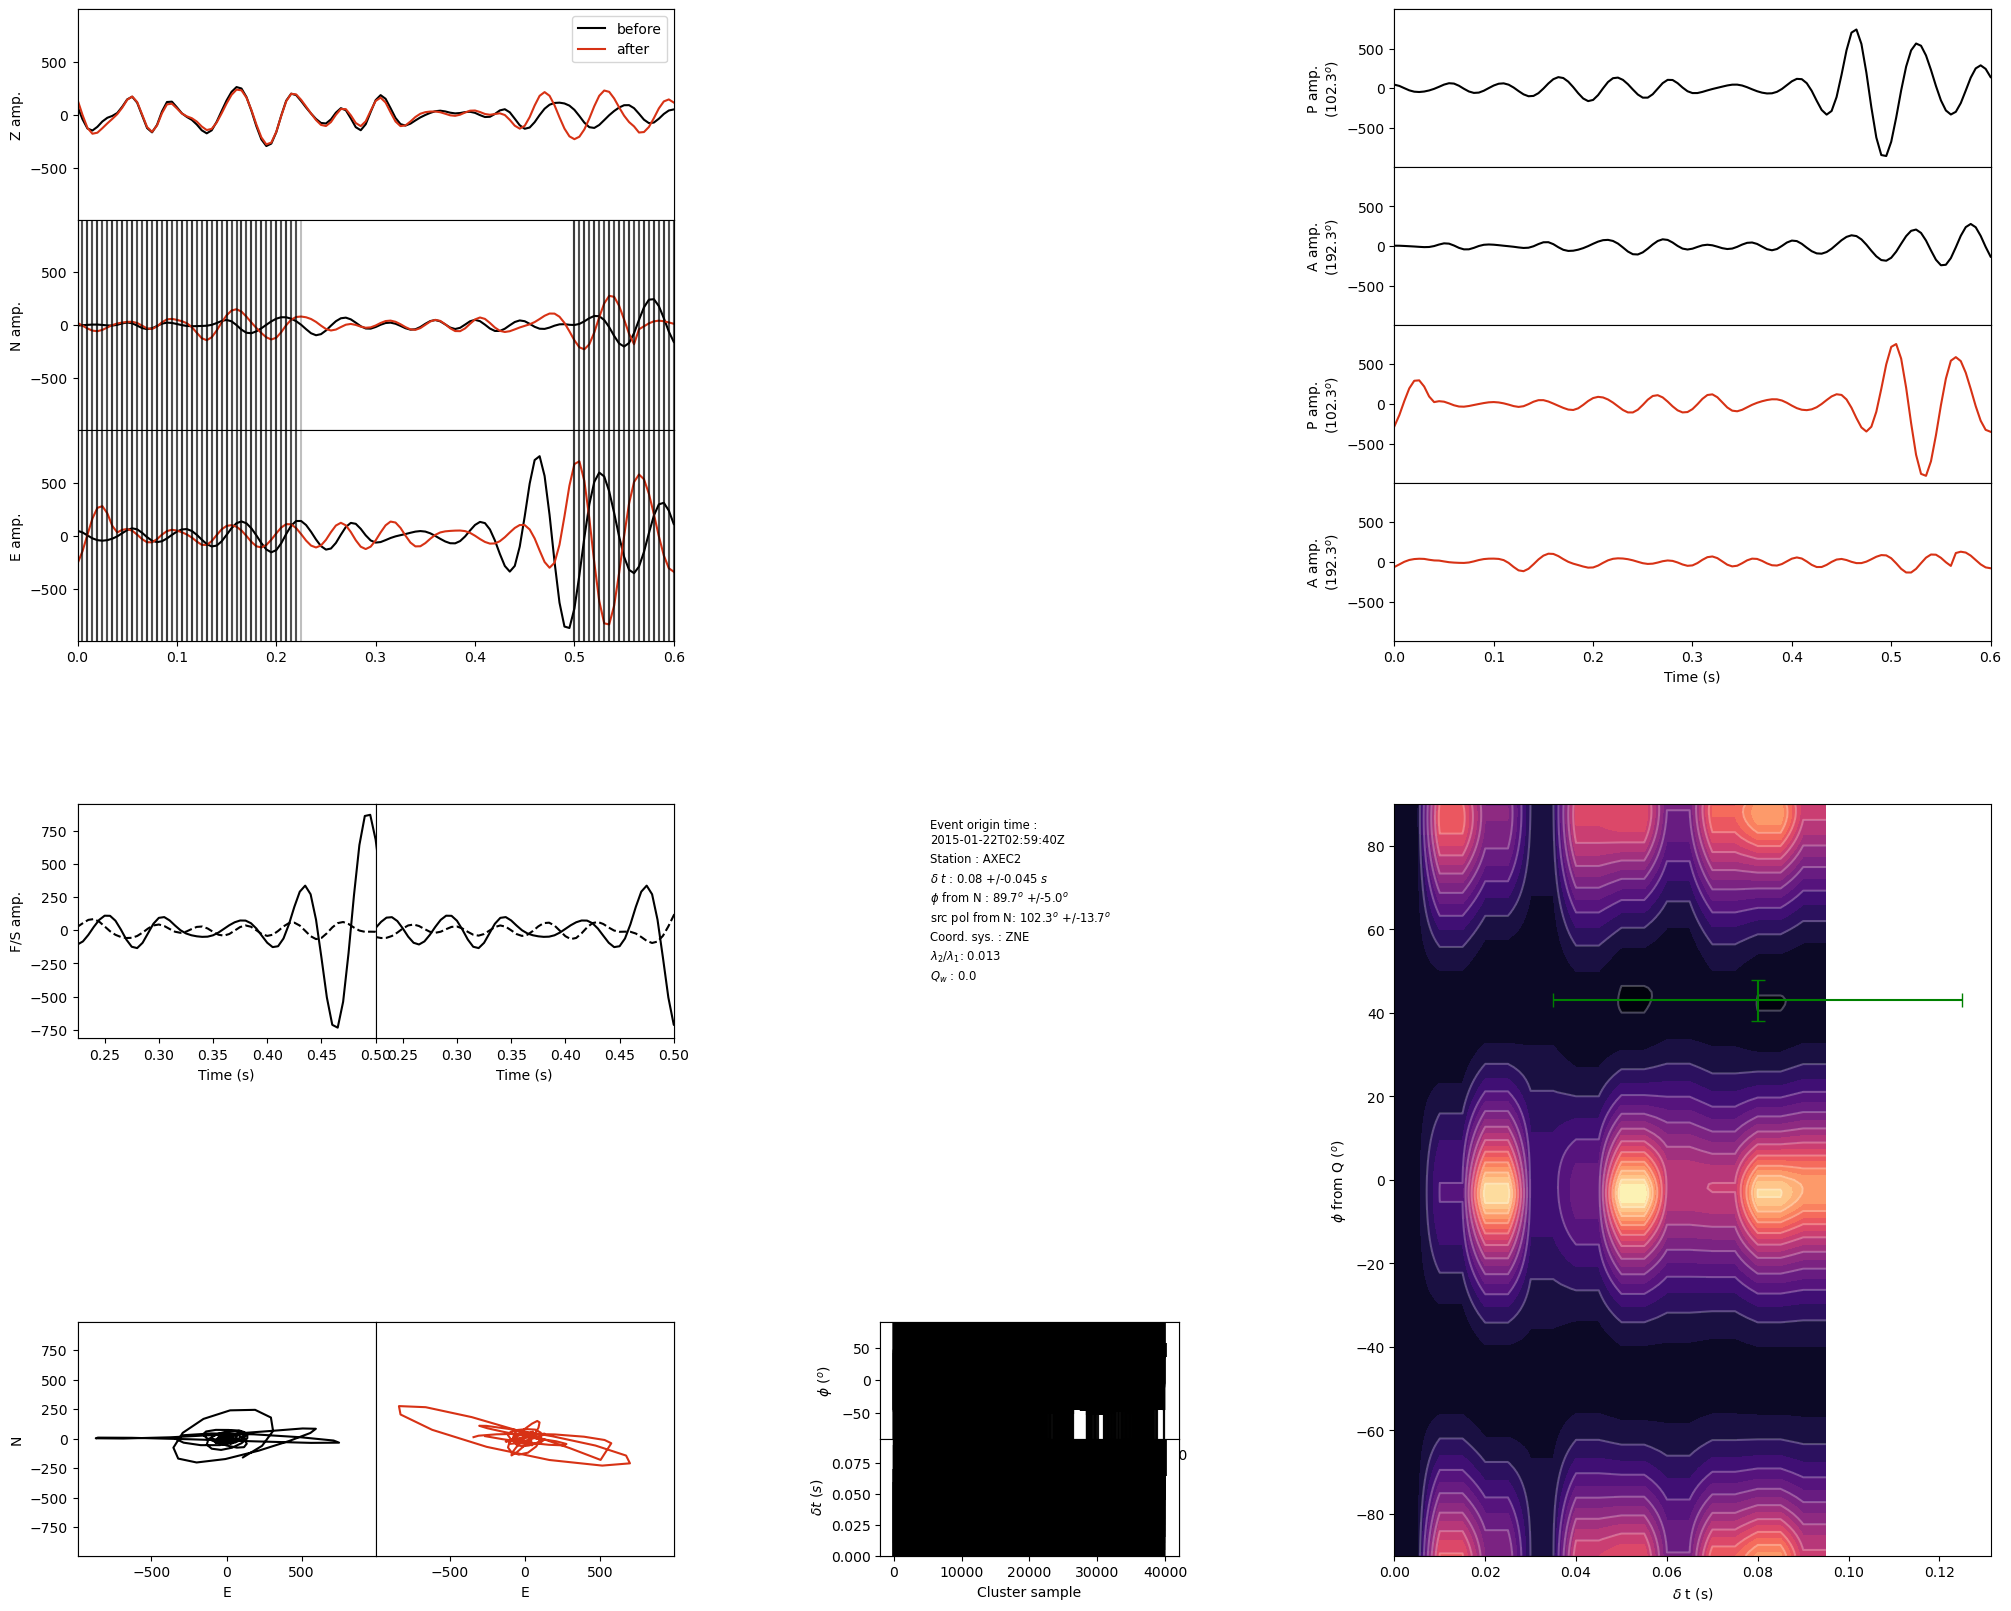

In [31]:

# Create splitting object and perform analysis
if prepared_st and len(prepared_st) >= 3 and hasattr(event_data, 's_arrival'):
    try:
        print("Step 1: Creating splitting object...")
        splitting_event = create_splitting_analysis(prepared_st, event_data, use_dynamic_params=True)
        
        print("\nStep 2: Performing shear-wave splitting analysis...")
        splitting_event.perform_sws_analysis(coord_system="ZNE", sws_method="EV_and_XC")
        
        print("\nStep 3: Plotting results...")
        splitting_event.plot()
        
            
    except Exception as e:
        print(f"Error in splitting analysis: {str(e)}")
else:
    missing_items = []
    if not prepared_st or len(prepared_st) < 3:
        missing_items.append("three-component seismic traces")
    if not hasattr(event_data, 's_arrival'):
        missing_items.append("S-arrival time")
    
    print(f"Cannot perform splitting analysis. Missing: {', '.join(missing_items)}")

In [32]:
# Create catalog with extended time windows for SNR calculation
# Need to start 4 seconds before event time to capture noise window before S-wave

extended_catalog = catalog.copy()

# Modify start times to be 4 seconds earlier
extended_catalog['extended_start'] = extended_catalog['datetime'].apply(
    lambda dt: UTCDateTime(dt) - 4
)

# Keep original end times (or extend slightly if needed)
if 'endtime' not in extended_catalog.columns:
    extended_catalog['endtime'] = extended_catalog['datetime'].apply(
        lambda dt: UTCDateTime(dt) + 15
    )

print("Creating extended waveform data with 4-second pre-event buffer...")
print(f"Original event start times vs extended start times:")
for i in range(min(3, len(extended_catalog))):
    orig_time = UTCDateTime(extended_catalog.iloc[i]['datetime'])
    ext_time = extended_catalog.iloc[i]['extended_start']
    print(f"  Event {i+1}: {orig_time} -> {ext_time} (4s earlier)")

# Save extended catalog for reference
extended_catalog.to_csv('../data/extended_catalog_for_snr.csv', index=False)
print("Extended catalog saved to ../data/extended_catalog_for_snr.csv")

# Download new waveform data with extended time windows
mseed_filename_extended = 'extended_catalog_waveforms_for_snr'
print(f"\nRetrieving extended waveform data for {len(extended_catalog)} events...")
print("This will download data starting 4 seconds before each event")

# Uncomment this line when ready to download:
get_all_traces(extended_catalog, mseed_filename_extended, 'extended_start', 'endtime')
print(f"Extended waveform data will be saved to: {mseed_filename_extended}.mseed")

Creating extended waveform data with 4-second pre-event buffer...
Original event start times vs extended start times:
  Event 1: 2015-01-22T02:59:40.845000Z -> 2015-01-22T02:59:36.845000Z (4s earlier)
  Event 2: 2015-01-22T02:59:40.845000Z -> 2015-01-22T02:59:36.845000Z (4s earlier)
Extended catalog saved to ../data/extended_catalog_for_snr.csv

Retrieving extended waveform data for 2 events...
This will download data starting 4 seconds before each event
Retrieved data for AXCC1 HHE from 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
Retrieved data for AXCC1 HHN from 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
Retrieved data for AXCC1 HHZ from 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
Retrieved data for AXCC1 HDH from 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
Retrieved data for AXEC1 EHE from 2015-01-22T02:59:36.845000Z to 2015-01-22T02:59:55.845000Z
Retrieved data for AXEC1 EHN from 2015-01-22T02:59:36.845000Z to 2015-01-22T

In [33]:
# We will now create another splitting object for the second event in the sample catalog
event_idx = 1  # Second event
event_data = sample_catalog.iloc[event_idx] # Get event data
print(f"Creating splitting analysis for event ID: {event_data['event_id']} at station: {event_data['station_id']}")
prepared_st = prepare_stream_for_splitting(st, event_data['station_id'], UTCDateTime(event_data['datetime']))
print(f"Prepared stream has {len(prepared_st)} traces for analysis")


Creating splitting analysis for event ID: 0.072 at station: AXEC2
Prepared stream contains 8 traces for station AXEC2
Components: ['E', 'E', 'N', 'N', 'Z', 'Z', 'H', 'H']
Prepared stream has 8 traces for analysis


In [34]:
prepared_st = prepared_st.remove(prepared_st[7])
prepared_st = prepared_st.remove(prepared_st[6])
prepared_st = prepared_st.remove(prepared_st[5])
prepared_st = prepared_st.remove(prepared_st[3])
prepared_st = prepared_st.remove(prepared_st[1])

Creating splitting object with dynamic parameters...
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Error estimating dominant period: PPSD.__init__() missing 1 required positional argument: 'metadata'
Dynamic parameters calculated:
  Dominant period: 0.100 s
  Dynamic window length: 0.500 s
  Optimal frequency range: 5.0-25.0 Hz
Performing shear-wave splitting analysis...
Plotting results...


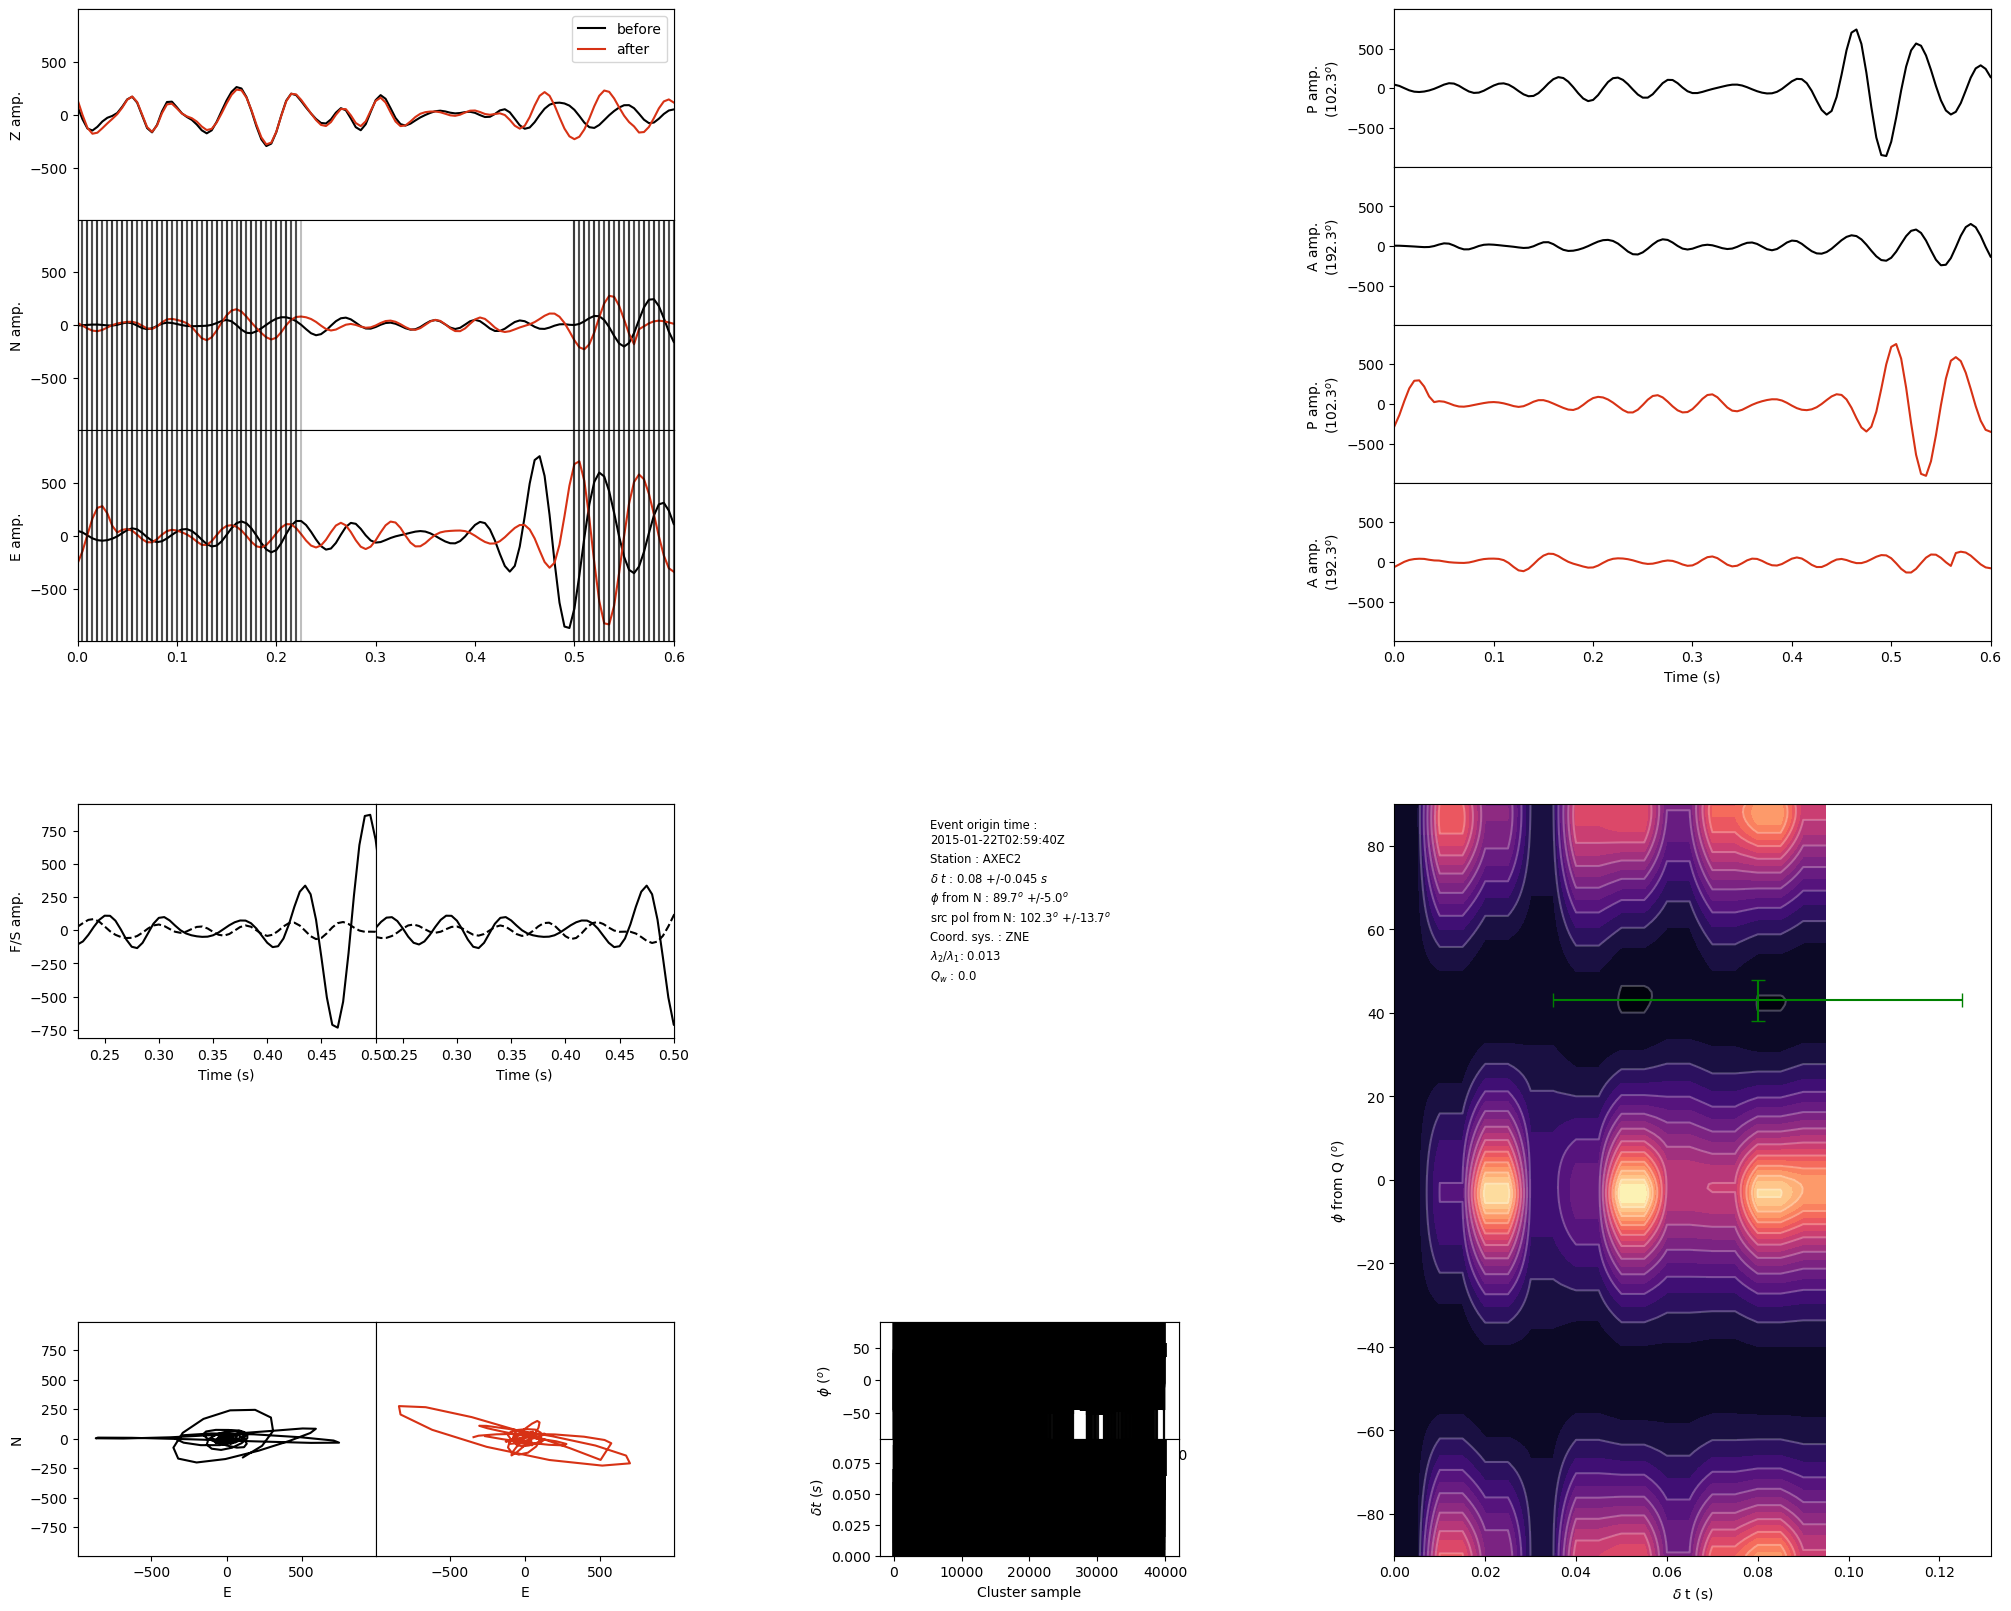

In [35]:
if prepared_st and len(prepared_st) >= 3 and hasattr(event_data, 's_arrival'):
    try:
        print("Creating splitting object with dynamic parameters...")
        splitting_event = create_splitting_analysis(prepared_st, event_data, use_dynamic_params=True)
        
        print("Performing shear-wave splitting analysis...")
        splitting_event.perform_sws_analysis(coord_system="ZNE", sws_method="EV_and_XC")
        
        print("Plotting results...")
        splitting_event.plot()
        
    except Exception as e:
        print(f"Error in splitting analysis: {str(e)}")


In [36]:
event_data

event_id                                        0.072
year                                             2015
lat                                          45.94606
lon                                        -129.98662
depth                                           1.305
magnitude                                         0.3
datetime                      2015-01-22 02:59:40.845
station_id                                      AXEC2
station_lat                                    45.955
station_lon                                  -129.973
station_elev                                   -1.519
back_azimuth                               226.653013
epicentral_distance_km                       1.448093
angle_of_incidence                           27.14788
endtime                       2015-01-22 02:59:55.845
p_arrival_time                                  0.425
s_arrival_time                                   0.81
rectilinearity                               0.947564
incidence_angle             